In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
cd "/content/drive/MyDrive/Courses/AI/masked_attention/llama_like"

/content/drive/MyDrive/Courses/AI/masked_attention/llama_like


In [3]:
import sys
sys.path.append("/content/drive/MyDrive/Courses/AI/masked_attention/")

In [4]:
import torch
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

from src.model import precompute_rope_freqs, apply_rope

In [5]:
# ---------------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------------
head_dim    = 16     # must be even
max_seq_len = 32
base        = 10000.0
T           = 16     # sequence length to inspect
torch.manual_seed(0)

In [6]:
# ---------------------------------------------------------------------------
# STEP 1 — Frequency computation
# ---------------------------------------------------------------------------
i      = torch.arange(0, head_dim, 2, dtype=torch.float32)   # (head_dim//2,)
theta  = 1.0 / (base ** (i / head_dim))                       # (head_dim//2,)

print("=" * 60)
print("STEP 1 — Rotation frequencies (theta_i)")
print("=" * 60)
print(f"  head_dim = {head_dim}  →  {head_dim//2} dimension pairs")
print(f"  formula  : theta_i = 1 / {base:.0f}^(2i / {head_dim})\n")
for idx, (dim_pair, th) in enumerate(zip(range(0, head_dim, 2), theta.tolist())):
    period = 2 * math.pi / th
    print(f"  pair {idx}  dims ({dim_pair},{dim_pair+1})  theta={th:.6f}  period={period:.1f} tokens")

STEP 1 — Rotation frequencies (theta_i)
  head_dim = 16  →  8 dimension pairs
  formula  : theta_i = 1 / 10000^(2i / 16)

  pair 0  dims (0,1)  theta=1.000000  period=6.3 tokens
  pair 1  dims (2,3)  theta=0.316228  period=19.9 tokens
  pair 2  dims (4,5)  theta=0.100000  period=62.8 tokens
  pair 3  dims (6,7)  theta=0.031623  period=198.7 tokens
  pair 4  dims (8,9)  theta=0.010000  period=628.3 tokens
  pair 5  dims (10,11)  theta=0.003162  period=1986.9 tokens
  pair 6  dims (12,13)  theta=0.001000  period=6283.2 tokens
  pair 7  dims (14,15)  theta=0.000316  period=19869.2 tokens


In [7]:
# ---------------------------------------------------------------------------
# STEP 2 — Rotation angles matrix  (position × dimension pair)
# ---------------------------------------------------------------------------
freqs     = precompute_rope_freqs(head_dim, max_seq_len, base)   # complex (T, head_dim//2)
angles    = torch.angle(freqs[:T])                                # (T, head_dim//2) in radians

print("\n" + "=" * 60)
print("STEP 2 — Rotation angles  [position × dim_pair]  (radians)")
print("=" * 60)
print(f"  Shape: {list(angles.shape)}  →  {T} positions × {head_dim//2} dim pairs\n")
header = "  pos  " + "  ".join(f"pair{j}" for j in range(head_dim // 2))
print(header)
print("  " + "-" * (len(header) - 2))
for pos in range(min(T, 8)):
    vals = "  ".join(f"{angles[pos, j].item():+.3f}" for j in range(head_dim // 2))
    print(f"  {pos:3d}  {vals}")
print("  ...")


STEP 2 — Rotation angles  [position × dim_pair]  (radians)
  Shape: [16, 8]  →  16 positions × 8 dim pairs

  pos  pair0  pair1  pair2  pair3  pair4  pair5  pair6  pair7
  -----------------------------------------------------------
    0  +0.000  +0.000  +0.000  +0.000  +0.000  +0.000  +0.000  +0.000
    1  +1.000  +0.316  +0.100  +0.032  +0.010  +0.003  +0.001  +0.000
    2  +2.000  +0.632  +0.200  +0.063  +0.020  +0.006  +0.002  +0.001
    3  +3.000  +0.949  +0.300  +0.095  +0.030  +0.009  +0.003  +0.001
    4  -2.283  +1.265  +0.400  +0.126  +0.040  +0.013  +0.004  +0.001
    5  -1.283  +1.581  +0.500  +0.158  +0.050  +0.016  +0.005  +0.002
    6  -0.283  +1.897  +0.600  +0.190  +0.060  +0.019  +0.006  +0.002
    7  +0.717  +2.214  +0.700  +0.221  +0.070  +0.022  +0.007  +0.002
  ...


In [8]:
# ---------------------------------------------------------------------------
# STEP 3 — Effect of RoPE on a single query vector
# ---------------------------------------------------------------------------
# Single query token at different positions
q_raw = torch.randn(1, T, 1, head_dim)   # (B=1, T, H=1, head_dim)
q_rot = apply_rope(q_raw.clone(), freqs)

print("\n" + "=" * 60)
print("STEP 3 — Query vector before vs after RoPE  (position 0 vs 4)")
print("=" * 60)
for pos in [0, 4]:
    raw = q_raw[0, pos, 0].tolist()
    rot = q_rot[0, pos, 0].tolist()
    print(f"\n  Position {pos}:")
    print(f"    before: {[f'{v:+.3f}' for v in raw[:6]]} ...")
    print(f"    after : {[f'{v:+.3f}' for v in rot[:6]]} ...")
    norm_before = q_raw[0, pos, 0].norm().item()
    norm_after  = q_rot[0, pos, 0].norm().item()
    print(f"    norm before={norm_before:.4f}  after={norm_after:.4f}  (preserved: {math.isclose(norm_before, norm_after, rel_tol=1e-4)})")

print("\n  → RoPE rotates the vector but preserves its norm.")
print("    Position information is encoded in the rotation angle.")


STEP 3 — Query vector before vs after RoPE  (position 0 vs 4)

  Position 0:
    before: ['-1.126', '-1.152', '-0.251', '-0.434', '+0.849', '+0.692'] ...
    after : ['-1.126', '-1.152', '-0.251', '-0.434', '+0.849', '+0.692'] ...
    norm before=3.6594  after=3.6594  (preserved: True)

  Position 4:
    before: ['-0.569', '+0.920', '+1.111', '+1.290', '-1.478', '+2.567'] ...
    after : ['+1.068', '-0.171', '-0.895', '+1.448', '-2.361', '+1.789'] ...
    norm before=4.4348  after=4.4348  (preserved: True)

  → RoPE rotates the vector but preserves its norm.
    Position information is encoded in the rotation angle.


In [9]:
# ---------------------------------------------------------------------------
# STEP 4 — Dot product Q·K depends only on relative position
# ---------------------------------------------------------------------------
# Fix a key at position 0, vary query position → dot product changes
k_pos0 = q_rot[0, 0, 0]   # reuse rotated q as k for simplicity

dots = []
for pos in range(T):
    q_pos = q_rot[0, pos, 0]
    dots.append((q_pos @ k_pos0).item())

print("\n" + "=" * 60)
print("STEP 4 — Dot product Q(pos) · K(pos=0)  vs relative distance")
print("=" * 60)
print(f"  {'rel_dist':>8}  {'dot product':>12}")
print(f"  {'-'*8}  {'-'*12}")
for pos in range(min(T, 10)):
    print(f"  {pos:>8}  {dots[pos]:>12.4f}")
print("  ...")
print("\n  → Dot product changes with relative distance,")
print("    encoding positional bias into attention scores.")



STEP 4 — Dot product Q(pos) · K(pos=0)  vs relative distance
  rel_dist   dot product
  --------  ------------
         0       13.3915
         1        1.3129
         2        0.3957
         3        1.0599
         4       -1.7662
         5       -6.3956
         6       -2.3345
         7        5.6915
         8       -0.7415
         9        2.0268
  ...

  → Dot product changes with relative distance,
    encoding positional bias into attention scores.



✓ Plot saved to rope_inspection.png


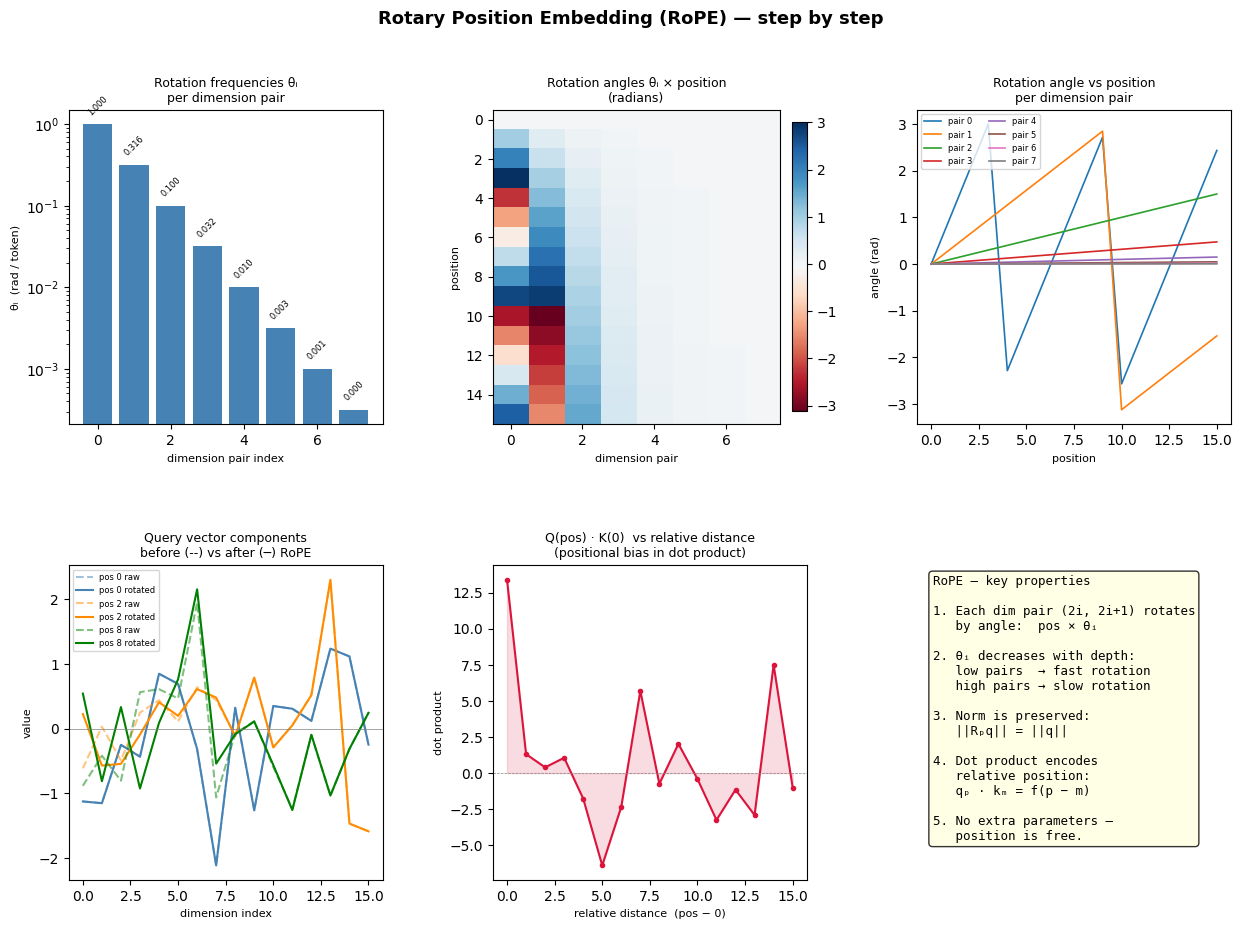

In [10]:
# ---------------------------------------------------------------------------
# STEP 5 — Visualization
# ---------------------------------------------------------------------------
fig = plt.figure(figsize=(15, 10))
fig.suptitle("Rotary Position Embedding (RoPE) — step by step",
             fontsize=13, fontweight="bold")
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Panel 0: theta frequencies ────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0, 0])
ax0.bar(range(head_dim // 2), theta.numpy(), color="steelblue")
ax0.set_title("Rotation frequencies θᵢ\nper dimension pair", fontsize=9)
ax0.set_xlabel("dimension pair index", fontsize=8)
ax0.set_ylabel("θᵢ  (rad / token)", fontsize=8)
ax0.set_yscale("log")
for idx, th in enumerate(theta.tolist()):
    ax0.text(idx, th * 1.3, f"{th:.3f}", ha="center", fontsize=6, rotation=45)

# ── Panel 1: rotation angle heatmap ──────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 1])
im1 = ax1.imshow(angles.numpy(), aspect="auto", cmap="RdBu", origin="upper")
ax1.set_title("Rotation angles θᵢ × position\n(radians)", fontsize=9)
ax1.set_xlabel("dimension pair", fontsize=8)
ax1.set_ylabel("position", fontsize=8)
plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

# ── Panel 2: angle per position for each dim pair (line plot) ─────────────
ax2 = fig.add_subplot(gs[0, 2])
positions = np.arange(T)
for j in range(head_dim // 2):
    ax2.plot(positions, angles[:T, j].numpy(), label=f"pair {j}", linewidth=1.2)
ax2.set_title("Rotation angle vs position\nper dimension pair", fontsize=9)
ax2.set_xlabel("position", fontsize=8)
ax2.set_ylabel("angle (rad)", fontsize=8)
ax2.legend(fontsize=6, ncol=2, loc="upper left")

# ── Panel 3: Q vector components before vs after RoPE ────────────────────
ax3 = fig.add_subplot(gs[1, 0])
pos_to_show = [0, 2, 8]
colors = ["steelblue", "darkorange", "green"]
for pos, col in zip(pos_to_show, colors):
    ax3.plot(q_raw[0, pos, 0].numpy(), linestyle="--", color=col, alpha=0.5,
             label=f"pos {pos} raw")
    ax3.plot(q_rot[0, pos, 0].numpy(), linestyle="-",  color=col,
             label=f"pos {pos} rotated")
ax3.set_title("Query vector components\nbefore (--) vs after (─) RoPE", fontsize=9)
ax3.set_xlabel("dimension index", fontsize=8)
ax3.set_ylabel("value", fontsize=8)
ax3.legend(fontsize=6)
ax3.axhline(0, color="gray", linewidth=0.5)

# ── Panel 4: dot product decay with relative distance ────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(range(T), dots, color="crimson", linewidth=1.5, marker="o", markersize=3)
ax4.axhline(0, color="gray", linewidth=0.5, linestyle="--")
ax4.set_title("Q(pos) · K(0)  vs relative distance\n(positional bias in dot product)", fontsize=9)
ax4.set_xlabel("relative distance  (pos − 0)", fontsize=8)
ax4.set_ylabel("dot product", fontsize=8)
ax4.fill_between(range(T), dots, alpha=0.15, color="crimson")

# ── Panel 5: summary diagram ──────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
ax5.axis("off")
lines = [
    "RoPE — key properties",
    "",
    "1. Each dim pair (2i, 2i+1) rotates",
    "   by angle:  pos × θᵢ",
    "",
    "2. θᵢ decreases with depth:",
    "   low pairs  → fast rotation",
    "   high pairs → slow rotation",
    "",
    "3. Norm is preserved:",
    "   ||Rₚq|| = ||q||",
    "",
    "4. Dot product encodes",
    "   relative position:",
    "   qₚ · kₘ = f(p − m)",
    "",
    "5. No extra parameters —",
    "   position is free.",
]
ax5.text(0.05, 0.97, "\n".join(lines), transform=ax5.transAxes,
         fontsize=9, verticalalignment="top", fontfamily="monospace",
         bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

plt.savefig("rope_inspection.png", dpi=150, bbox_inches="tight")
print("\n✓ Plot saved to rope_inspection.png")
plt.show()
